# Colab baseline v1

本 notebook 只做一件事：
- 重新建立 Colab 环境
- 跑一轮干净的 MAPPO baseline on VMAS/navigation
- 列出 outputs
- 用 metrics_summary.py 汇总结果


## 1. Clone repo

In [1]:
!git clone https://github.com/WonderfulClaire/low_altitude_marl.git
%cd /content/low_altitude_marl
!ls

Cloning into 'low_altitude_marl'...
remote: Enumerating objects: 206, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 206 (delta 7), reused 0 (delta 0), pack-reused 187 (from 1)
Receiving objects: 100% (206/206), 230.99 KiB | 3.16 MiB/s, done.
Resolving deltas: 100% (98/98), done.
/content/low_altitude_marl
notebooks  README.md  requirements.txt	src


## 2. Install dependencies

In [2]:
%cd /content/low_altitude_marl
!python -m pip install --upgrade pip
!python -m pip install -r requirements.txt

/content/low_altitude_marl
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 19.8 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 10.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 56.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 54.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 105.3 MB/s  0:00:00
  Created wheel for vmas: filename=vmas-1.5.2-py3-none-any.whl size=260328 sha256=f73d9f8e1f299cd1a2f4602775

## 3. Check torch and GPU

In [3]:
import torch
print('torch version:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
print('gpu count:', torch.cuda.device_count())
if torch.cuda.is_available():
    print('gpu name:', torch.cuda.get_device_name(0))

torch version: 2.10.0+cpu
cuda available: False
gpu count: 0


## 4. Run MAPPO baseline (short run)

In [4]:
%cd /content/low_altitude_marl
import os
os.environ['WANDB_MODE'] = 'disabled'

!python -m benchmarl.run \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=300000 \
  seed=0

/content/low_altitude_marl

Algorithm: mappo, Task: vmas/navigation

Loaded config:

experiment:
  sampling_device: cpu
  train_device: cpu
  buffer_device: cpu
  share_policy_params: true
  prefer_continuous_actions: true
  collect_with_grad: false
  parallel_collection: false
  gamma: 0.99
  lr: 5.0e-05
  adam_eps: 1.0e-06
  adam_extra_kwargs: {}
  clip_grad_norm: true
  clip_grad_val: 5.0
  soft_target_update: true
  polyak_tau: 0.005
  hard_target_update_frequency: 5
  exploration_eps_init: 0.8
  exploration_eps_end: 0.01
  exploration_anneal_frames: null
  max_n_iters: null
  max_n_frames: 300000
  on_policy_collected_frames_per_batch: 6000
  on_policy_n_envs_per_worker: 10
  on_policy_n_minibatch_iters: 45
  on_policy_minibatch_size: 400
  off_policy_collected_frames_per_batch: 6000
  off_policy_n_envs_per_worker: 10
  off_policy_n_optimizer_steps: 1000
  off_policy_train_batch_size: 128
  off_policy_memory_size: 1000000
  off_policy_init_random_frames: 0
  off_policy_use_priorit

## 5. List outputs

In [5]:
%cd /content/low_altitude_marl
!find outputs -maxdepth 3 -type d | sort

/content/low_altitude_marl
outputs
outputs/2026-04-26
outputs/2026-04-26/21-02-45
outputs/2026-04-26/21-02-45/.hydra
outputs/2026-04-26/21-02-45/mappo_navigation_mlp__200db235_26_04_26-21_02_45


## 6. Summarize latest run
把下面 `RUN_ROOT` 改成上一个 cell 里最新生成的时间目录。

In [8]:
%cd /content/low_altitude_marl
RUN_ROOT = '/content/low_altitude_marl/outputs/2026-04-26/21-02-45'
!python src/metrics_summary.py "$RUN_ROOT"

/content/low_altitude_marl
Run root: /content/low_altitude_marl/outputs/2026-04-26/21-02-45

=== collection_reward_episode_reward_mean.csv ===
   step     value
0     0 -0.442668
1     1 -0.315566
2     2 -0.183335
3     3 -0.027397
4     4  0.463985
...
    step     value
45    45  0.934863
46    46  0.907096
47    47  0.907066
48    48  0.971767
49    49  0.963188
last value: 0.9631877541542052

=== collection_reward_reward_mean.csv ===
   step     value
0     0 -0.004427
1     1 -0.003156
2     2 -0.001833
3     3 -0.000274
4     4  0.004640
...
    step     value
45    45  0.019584
46    46  0.020822
47    47  0.019876
48    48  0.021504
49    49  0.020013
last value: 0.0200127325952053

=== train_agents_loss_critic.csv ===
   step     value
0     0  0.052233
1     1  0.065900
2     2  0.074620
3     3  0.069300
4     4  0.018173
...
    step     value
45    45  0.017057
46    46  0.015096
47    47  0.022054
48    48  0.015710
49    49  0.023640
last value: 0.0236398037523031

=== 

## 7. Optional: quick plot of episode_reward_mean

target: /content/low_altitude_marl/outputs/2026-04-26/21-02-45/mappo_navigation_mlp__200db235_26_04_26-21_02_45/mappo_navigation_mlp__200db235_26_04_26-21_02_45/scalars/collection_reward_episode_reward_mean.csv


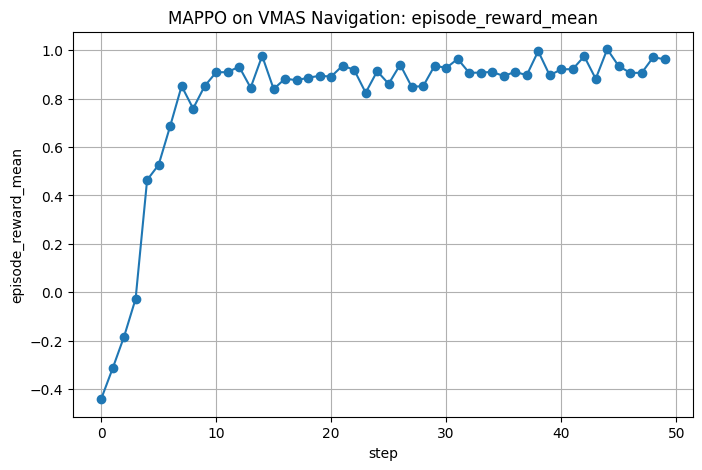

In [9]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

root = Path(RUN_ROOT)
target = None
for p in root.rglob('collection_reward_episode_reward_mean.csv'):
    target = p
    break
print('target:', target)
df = pd.read_csv(target, header=None, names=['step', 'value'])
plt.figure(figsize=(8,5))
plt.plot(df['step'], df['value'], marker='o')
plt.xlabel('step')
plt.ylabel('episode_reward_mean')
plt.title('MAPPO on VMAS Navigation: episode_reward_mean')
plt.grid(True)
plt.show()

In [10]:
import pandas as pd
import numpy as np
from pathlib import Path

# 自动找最新的 mappo_navigation_mlp run 目录
roots = sorted(Path("/content/low_altitude_marl/outputs").glob("*/**/mappo_navigation_mlp__*"))
if not roots:
    raise FileNotFoundError("No mappo_navigation_mlp__* run directory found under outputs.")

RUN_ROOT = roots[-1]
print("RUN_ROOT =", RUN_ROOT)

def read_metric_csv(csv_path):
    df = pd.read_csv(csv_path)

    step_col = None
    value_col = None

    for c in df.columns:
        lc = str(c).lower()
        if step_col is None and lc in ["step", "global_step", "wall_step", "_step"]:
            step_col = c
        if value_col is None and lc in ["value", "scalar", "episode_reward_mean", "reward_mean"]:
            value_col = c

    if step_col is None:
        step_col = df.columns[0]
    if value_col is None:
        value_col = df.columns[-1]

    out = df[[step_col, value_col]].copy()
    out.columns = ["step", "value"]
    out["step"] = pd.to_numeric(out["step"], errors="coerce")
    out["value"] = pd.to_numeric(out["value"], errors="coerce")
    out = out.dropna().sort_values("step").reset_index(drop=True)
    return out

def summarize_curve(df):
    x = df["step"].to_numpy(dtype=float)
    y = df["value"].to_numpy(dtype=float)

    if len(y) == 0:
        return None

    dy = np.diff(y) if len(y) >= 2 else np.array([0.0])
    pos_idx = np.where(y > 0)[0]

    return {
        "n_points": int(len(y)),
        "final": float(y[-1]),
        "best": float(np.max(y)),
        "best_step": int(x[np.argmax(y)]) if len(x) else None,
        "last3_mean": float(np.mean(y[-3:])),
        "auc": float(np.trapz(y, x)) if len(y) >= 2 else 0.0,
        "first_positive_step": int(x[pos_idx[0]]) if len(pos_idx) > 0 else None,
        "early_min": float(np.min(y[:max(1, len(y)//3)])),
        "volatility": float(np.std(dy)),
    }

# 常见指标文件名
target_metrics = [
    "collection_reward_episode_reward_mean.csv",
    "collection_reward_reward_mean.csv",
    "collection_agents_reward_episode_reward_mean.csv",
    "collection_agents_reward_reward_mean.csv",
    "collection_agents_info_agent_collisions.csv",
    "collection_agents_info_pos_rew.csv",
    "collection_agents_info_final_rew.csv",
    "train_agents_loss_critic.csv",
    "train_agents_loss_objective.csv",
]

rows = []

print("\nAll csv files found:")
all_csvs = sorted(RUN_ROOT.rglob("*.csv"))
for p in all_csvs:
    print(" -", p.relative_to(RUN_ROOT))

print("\nMetric summary:")
for metric in target_metrics:
    matches = list(RUN_ROOT.rglob(metric))
    if not matches:
        print("[missing]", metric)
        continue

    csv_path = matches[-1]
    df = read_metric_csv(csv_path)
    s = summarize_curve(df)
    if s is None:
        continue

    row = {"metric": metric}
    row.update(s)
    rows.append(row)

summary = pd.DataFrame(rows)
display(summary)

out_path = RUN_ROOT / "metric_summary_extracted.csv"
summary.to_csv(out_path, index=False)
print("\nSaved:", out_path)

RUN_ROOT = /content/low_altitude_marl/outputs/2026-04-26/21-02-45/mappo_navigation_mlp__200db235_26_04_26-21_02_45/mappo_navigation_mlp__200db235_26_04_26-21_02_45

All csv files found:
 - scalars/collection_agents_info_agent_collisions.csv
 - scalars/collection_agents_info_final_rew.csv
 - scalars/collection_agents_info_pos_rew.csv
 - scalars/collection_agents_reward_episode_reward_max.csv
 - scalars/collection_agents_reward_episode_reward_mean.csv
 - scalars/collection_agents_reward_episode_reward_min.csv
 - scalars/collection_reward_episode_reward_max.csv
 - scalars/collection_reward_episode_reward_mean.csv
 - scalars/collection_reward_episode_reward_min.csv
 - scalars/collection_reward_reward_max.csv
 - scalars/collection_reward_reward_mean.csv
 - scalars/collection_reward_reward_min.csv
 - scalars/counters_current_frames.csv
 - scalars/counters_iter.csv
 - scalars/counters_total_frames.csv
 - scalars/timers_collection_time.csv
 - scalars/timers_iteration_time.csv
 - scalars/timers

/tmp/ipykernel_1575/101396955.py:54: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "auc": float(np.trapz(y, x)) if len(y) >= 2 else 0.0,
/tmp/ipykernel_1575/101396955.py:54: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "auc": float(np.trapz(y, x)) if len(y) >= 2 else 0.0,
/tmp/ipykernel_1575/101396955.py:54: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "auc": float(np.trapz(y, x)) if len(y) >= 2 else 0.0,
/tmp/ipykernel_1575/101396955.py:54: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "auc": float(np.trapz(y, x)) if len(y) >= 2 else 0.0,
/tmp/ipykernel_1575/101396955.py:54: DeprecationWarning: `trapz` is deprecated. Use 

,metric,n_points,final,best,best_step,last3_mean,auc,first_positive_step,early_min,volatility
0,collection_reward_episode_reward_mean.csv,49,0.963188,1.004795,44,0.947340,39.780326,4.0,-0.315566,0.099929
1,collection_reward_reward_mean.csv,49,0.020013,0.021504,48,0.020464,0.665144,4.0,-0.003156,0.001322
2,collection_agents_reward_episode_reward_mean.csv,49,0.963188,1.004795,44,0.947340,39.780326,4.0,-0.315566,0.099929
3,collection_agents_info_agent_collisions.csv,49,-0.002444,-0.000111,7,-0.001963,-0.083389,NaN,-0.005889,0.000928
4,collection_agents_info_pos_rew.csv,49,0.022457,0.022726,48,0.022427,0.748533,1.0,0.002733,0.000744
5,collection_agents_info_final_rew.csv,49,0.000000,0.000000,1,0.000000,0.000000,NaN,0.000000,0.000000
6,train_agents_loss_critic.csv,49,0.023640,0.074620,2,0.020468,0.979557,1.0,0.006124,0.009799
7,train_agents_loss_objective.csv,49,0.008547,0.022577,1,0.003978,-0.262586,1.0,-0.053410,0.010711



Saved: /content/low_altitude_marl/outputs/2026-04-26/21-02-45/mappo_navigation_mlp__200db235_26_04_26-21_02_45/mappo_navigation_mlp__200db235_26_04_26-21_02_45/metric_summary_extracted.csv


In [11]:
from pathlib import Path
import datetime
import os
import shutil
from google.colab import files

REPO = Path("/content/low_altitude_marl")
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
backup_dir = Path(f"/content/backup_low_altitude_marl_{timestamp}")
zip_path = Path(f"/content/backup_low_altitude_marl_{timestamp}.zip")

backup_dir.mkdir(parents=True, exist_ok=True)

# 备份实验输出
for name in ["outputs", "results", "src", "notebooks"]:
    src = REPO / name
    if src.exists():
        shutil.copytree(src, backup_dir / name, dirs_exist_ok=True)
        print(f"Copied: {src}")
    else:
        print(f"Missing, skipped: {src}")

# 备份当前 git 信息，方便之后知道当时用的是哪个版本
if REPO.exists():
    os.system(f"cd {REPO} && git status > {backup_dir}/git_status.txt")
    os.system(f"cd {REPO} && git log --oneline -20 > {backup_dir}/git_log_last20.txt")
    os.system(f"find {REPO}/outputs -maxdepth 5 -type d | sort > {backup_dir}/outputs_tree.txt")
    os.system(f"find {REPO}/outputs -name '*.csv' | sort > {backup_dir}/csv_files.txt")

# 打包
shutil.make_archive(str(zip_path).replace(".zip", ""), "zip", backup_dir)

print("Backup zip:", zip_path)
files.download(str(zip_path))

Copied: /content/low_altitude_marl/outputs
Missing, skipped: /content/low_altitude_marl/results
Copied: /content/low_altitude_marl/src
Copied: /content/low_altitude_marl/notebooks
Backup zip: /content/backup_low_altitude_marl_20260426_225025.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>